**Lab2-DL: A2-PyTorch-Lightning.ipynb** (BMED365) | Priority: 3 (optional)

_A brief introduction to **PyTorch** and **Lightning** for medical students – AI-assisted notebook_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/A2-PyTorch-Lightning.ipynb)

Last updated: 2025-12-22, A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

# Introduction to PyTorch and Lightning for Medical AI

## Overview

| Tool | Analogy | Role |
|------|---------|------|
| **PyTorch** | Your digital microscope | Build and train neural networks |
| **Lightning** | Well-organized laboratory protocol | Structure experiments, automate training |

### Why these tools?
- 🔬 **PyTorch**: Popular in medical image analysis, biosignals, and tabular data (TabPFN)
- ⚡ **Lightning**: Ensures reproducibility – crucial for clinical research
- 🖥️ **GPU acceleration**: Essential for large medical datasets

Let's look at **executable examples** that demonstrate the concepts!

### Example 1: PyTorch Tensors (the foundation)

A **tensor** in PyTorch is like a multi-dimensional table of numbers – the foundation of all deep learning. Think of it as:
- 1D tensor = a blood test with multiple values (Hb, leukocytes, platelets)
- 2D tensor = an ECG recording (time × leads)  
- 3D tensor = a CT slice (height × width × channels)
- 4D tensor = a batch of CT slices (batch × height × width × channels)


In [2]:
# === PyTorch Tensors: Basic example ===
import torch
import numpy as np

# 1. Create a tensor from a "blood test" (simulated)
blood_test = torch.tensor([14.2, 7.5, 250.0])  # Hb, leukocytes, platelets
print(f"Blood test (1D tensor): {blood_test}")
print(f"  Shape: {blood_test.shape}")

# 2. Create a 2D tensor simulating ECG (5 time points × 3 leads)
ecg_data = torch.randn(5, 3)  # Random values
print(f"\nECG data (2D tensor):\n{ecg_data}")
print(f"  Shape: {ecg_data.shape}")

# 3. Create a "medical image" (28×28 pixels, like MNIST)
image = torch.randn(1, 28, 28)  # 1 channel, 28×28
print(f"\nImage tensor shape: {image.shape} (channels × height × width)")

# 4. Batch of 4 images (typical input to a neural network)
batch_images = torch.randn(4, 1, 28, 28)  # 4 images
print(f"Batch shape: {batch_images.shape} (batch × channels × height × width)")

# 5. Simple operation: Normalize blood test values
normalized = (blood_test - blood_test.mean()) / blood_test.std()
print(f"\nNormalized blood test: {normalized}")


Blood test (1D tensor): tensor([ 14.2000,   7.5000, 250.0000])
  Shape: torch.Size([3])

ECG data (2D tensor):
tensor([[-4.3394e-02, -3.9739e-01, -1.6661e-01],
        [-3.0800e-01,  1.0279e+00,  1.1972e+00],
        [ 3.1845e-01, -3.2644e-01,  8.4480e-04],
        [-6.5380e-01,  1.1688e+00, -7.0491e-01],
        [-2.6904e-01, -9.6777e-02, -2.1859e-01]])
  Shape: torch.Size([5, 3])

Image tensor shape: torch.Size([1, 28, 28]) (channels × height × width)
Batch shape: torch.Size([4, 1, 28, 28]) (batch × channels × height × width)

Normalized blood test: tensor([-0.5529, -0.6014,  1.1544])


### Example 2: Simple Neural Network in PyTorch

Let's build a minimal network that can classify "patients" based on 3 measurements (like blood test values) into 2 categories (healthy/sick).


In [3]:
# === Simple neural network: Classify patients ===
import torch
import torch.nn as nn

# Define a minimal network
class SimpleClassifier(nn.Module):
    """
    A simple network for binary classification.
    Input: 3 values (e.g., Hb, leukocytes, CRP)
    Output: 2 classes (healthy=0, sick=1)
    """
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 8)    # 3 input → 8 hidden neurons
        self.layer2 = nn.Linear(8, 2)    # 8 hidden → 2 output classes
        self.activation = nn.ReLU()      # Activation function
        
    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.layer2(x)
        return x

# Create the model
model = SimpleClassifier()
print("Model architecture:")
print(model)

# Simulate a "patient" with 3 measurements
patient = torch.tensor([[14.0, 8.5, 15.0]])  # Hb, leukocytes, CRP
print(f"\nPatient data (input): {patient}")

# Run through the network (forward pass)
output = model(patient)
print(f"Network output (raw): {output}")

# Convert to probabilities
probabilities = torch.softmax(output, dim=1)
print(f"Probabilities: Healthy={probabilities[0,0]:.2%}, Sick={probabilities[0,1]:.2%}")

# Prediction
prediction = torch.argmax(probabilities, dim=1)
print(f"Prediction: {'Sick' if prediction.item() == 1 else 'Healthy'}")


Model architecture:
SimpleClassifier(
  (layer1): Linear(in_features=3, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=2, bias=True)
  (activation): ReLU()
)

Patient data (input): tensor([[14.0000,  8.5000, 15.0000]])
Network output (raw): tensor([[-0.0358,  2.8149]], grad_fn=<AddmmBackward0>)
Probabilities: Healthy=5.46%, Sick=94.54%
Prediction: Sick


### Example 3: Training Loop in Pure PyTorch

Now we train the model on simulated patient data. This shows the **manual** way – Lightning simplifies this significantly!


In [4]:
# === Training loop: Manual PyTorch ===

# Generate simulated patient data (100 patients)
torch.manual_seed(42)
X_train = torch.randn(100, 3)  # 100 patients, 3 measurements each
y_train = (X_train[:, 2] > 0).long()  # Sick if CRP (column 3) > 0

# Create new model and define loss/optimizer
model = SimpleClassifier()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training loop
print("Training starting...")
for epoch in range(50):
    # Forward pass
    predictions = model(X_train)
    loss = loss_function(predictions, y_train)
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Log every 10th epoch
    if (epoch + 1) % 10 == 0:
        accuracy = (predictions.argmax(dim=1) == y_train).float().mean()
        print(f"  Epoch {epoch+1:3d}: Loss={loss.item():.4f}, Accuracy={accuracy:.1%}")

print("\nTraining complete!")


Training starting...
  Epoch  10: Loss=0.5874, Accuracy=77.0%
  Epoch  20: Loss=0.4780, Accuracy=85.0%
  Epoch  30: Loss=0.3572, Accuracy=88.0%
  Epoch  40: Loss=0.2489, Accuracy=93.0%
  Epoch  50: Loss=0.1727, Accuracy=97.0%

Training complete!


### Example 4: Same Model with PyTorch Lightning

Lightning structures your code and handles training logic automatically. Compare with the manual loop above!

**Note:** If Lightning is not installed, run the cell below first:


In [5]:
# === Install Lightning if necessary ===
# Run this cell ONLY if you get an ImportError for Lightning

# !pip install lightning --quiet


In [6]:
# === Same model with PyTorch Lightning ===
# Lightning has changed package names - try both variants
try:
    import lightning.pytorch as pl  # New name (v2.0+)
except ImportError:
    import pytorch_lightning as pl  # Old name
    
from torch.utils.data import DataLoader, TensorDataset

class PatientClassifier(pl.LightningModule):
    """
    Lightning version of our patient classifier.
    All training logic is structured in methods.
    """
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(3, 8)
        self.layer2 = nn.Linear(8, 2)
        self.activation = nn.ReLU()
        self.loss_function = nn.CrossEntropyLoss()
        
    def forward(self, x):
        x = self.activation(self.layer1(x))
        return self.layer2(x)
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = self.loss_function(pred, y)
        accuracy = (pred.argmax(dim=1) == y).float().mean()
        self.log('loss', loss, prog_bar=True)
        self.log('accuracy', accuracy, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.01)

# Create dataset and dataloader
dataset = TensorDataset(X_train, y_train)

# Note: num_workers=0 is required on macOS/Apple Silicon
# On Linux/Windows with CUDA you can use num_workers>0 for faster data loading
import platform
num_workers = 0 if platform.system() == 'Darwin' else 4

dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=num_workers)

# Create Lightning model and trainer
lightning_model = PatientClassifier()
trainer = pl.Trainer(
    max_epochs=50, 
    enable_progress_bar=True,
    enable_model_summary=False,
    logger=False  # Disable logging for simpler output
)

# Train the model (one line!)
print("Lightning training starting...")
trainer.fit(lightning_model, dataloader)
print("Training complete!")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/envs/bmed365-2026/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Lightning training starting...


Output()

`Trainer.fit` stopped: `max_epochs=50` reached.


Training complete!


> **Note on Lightning output:** The "litmodels" tip and "num_workers" warning in the output above are informational messages and can be safely ignored. The `num_workers=0` setting is intentional for macOS compatibility with MPS (Metal) GPU acceleration. On Linux/Windows with NVIDIA CUDA, higher values can be used for faster data loading.


### Summary: PyTorch vs Lightning

| Aspect | Pure PyTorch | PyTorch Lightning |
|--------|--------------|-------------------|
| **Training loop** | Manual (for-loop) | Automatic (`trainer.fit()`) |
| **Code structure** | Free-form, can get messy | Organized in methods |
| **Logging** | Manual `print()` | Built-in `self.log()` |
| **GPU support** | Manual `.to(device)` | Automatic |
| **Checkpointing** | Manual saving | Built-in |

**When to use what?**
- 🔧 **Pure PyTorch**: To understand what's happening, experimentation, simple tasks
- ⚡ **Lightning**: For production code, larger projects, reproducible research

### Platform-specific notes

| Platform | Accelerator | `num_workers` in DataLoader |
|----------|-------------|----------------------------|
| **Apple Silicon** (M1–M4) | MPS (Metal) | Must be `0` due to multiprocessing limitations |
| **NVIDIA GPU** | CUDA | Can be `>0` for parallel loading |
| **CPU** | – | Can be `>0` |

> 💡 **Tip:** PyTorch supports Apple Silicon via **MPS** (Metal Performance Shaders). Lightning detects this automatically!

---

*The rest of this notebook uses these tools on EEG data for epilepsy detection!*


## Medical Image Classification: Complete Example

Now we'll build a **complete, executable example** that simulates medical image classification. We use synthetic data to demonstrate the concepts.

### Key Components

| Component | Medical analogy | PyTorch class |
|-----------|-----------------|---------------|
| **Dataset** | Patient database with images and diagnoses | `torch.utils.data.Dataset` |
| **DataLoader** | System for fetching samples in batches | `DataLoader` |
| **Model** | Diagnostic protocol | `nn.Module` / `LightningModule` |
| **Training** | Doctor learning from experience | `Trainer.fit()` |


### Example 5: Synthetic Medical Image Dataset

We create a **synthetic dataset** that simulates medical images. This demonstrates the entire pipeline without downloading real data.


In [7]:
# === Synthetic medical image dataset ===
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

class SyntheticXrayDataset(Dataset):
    """
    Simulates a dataset of "X-ray images" (32x32 pixels).
    - Class 0 (Normal): Uniform gray tone with little noise
    - Class 1 (Pathological): Has a "lesion" (brighter circle)
    """
    def __init__(self, n_samples=200):
        self.n_samples = n_samples
        self.images = []
        self.labels = []
        
        for i in range(n_samples):
            if i < n_samples // 2:
                # Normal: uniform gray tone
                image = 0.3 + 0.1 * np.random.randn(32, 32)
                label = 0
            else:
                # Pathological: has a "lesion" (brighter circle)
                image = 0.3 + 0.1 * np.random.randn(32, 32)
                # Add circular lesion at random position
                cx, cy = np.random.randint(8, 24, 2)
                y, x = np.ogrid[:32, :32]
                mask = (x - cx)**2 + (y - cy)**2 < 25  # Circle with radius ~5
                image[mask] += 0.4  # Brighter area
                label = 1
            
            self.images.append(torch.tensor(image, dtype=torch.float32).unsqueeze(0))
            self.labels.append(label)
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Create dataset
dataset = SyntheticXrayDataset(n_samples=200)
print(f"Dataset created: {len(dataset)} images")
print(f"Image shape: {dataset[0][0].shape} (channels × height × width)")


Dataset created: 200 images
Image shape: torch.Size([1, 32, 32]) (channels × height × width)


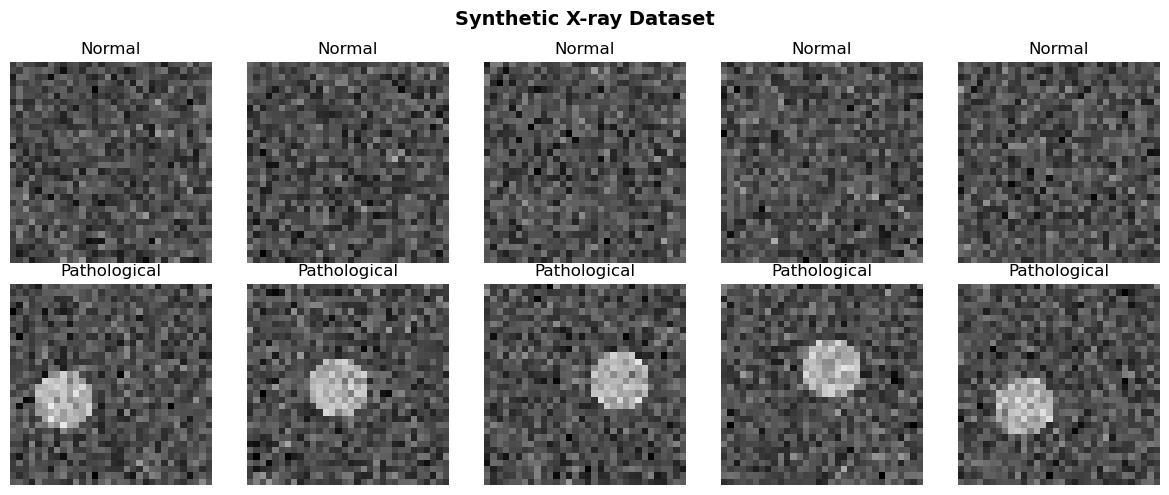

💡 Notice the brighter 'lesions' in the pathological images!


In [8]:
# === Visualize examples from the dataset ===
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Synthetic X-ray Dataset', fontsize=14, fontweight='bold')

# Show 5 normal images
for i in range(5):
    image, label = dataset[i]
    axes[0, i].imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title('Normal' if label == 0 else 'Pathological')
    axes[0, i].axis('off')

# Show 5 pathological images
for i in range(5):
    image, label = dataset[100 + i]  # From second half
    axes[1, i].imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title('Normal' if label == 0 else 'Pathological')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Normal', fontsize=12)
axes[1, 0].set_ylabel('Pathological', fontsize=12)
plt.tight_layout()
plt.show()

print("💡 Notice the brighter 'lesions' in the pathological images!")


### Example 6: CNN for Image Classification

Now we build a **Convolutional Neural Network (CNN)** that can learn to distinguish normal from pathological images.


In [9]:
# === CNN for medical image classification ===

# Lightning import
try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class MedicalImageCNN(pl.LightningModule):
    """
    CNN for binary classification of medical images.
    Architecture: Conv → Pool → Conv → Pool → FC → Output
    """
    def __init__(self):
        super().__init__()
        
        # Convolutional layers (feature extraction)
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 32x32 → 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32x32 → 16x16
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16x16 → 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16x16 → 8x8
        )
        
        # Classification layers
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # 2 classes: normal/pathological
        )
        
        self.loss_function = nn.CrossEntropyLoss()
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
    def training_step(self, batch, batch_idx):
        images, labels = batch
        pred = self(images)
        loss = self.loss_function(pred, labels)
        accuracy = (pred.argmax(dim=1) == labels).float().mean()
        self.log('loss', loss, prog_bar=True)
        self.log('accuracy', accuracy, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

# Create model and display architecture
cnn_model = MedicalImageCNN()
print("CNN architecture:")
print(cnn_model)


CNN architecture:
MedicalImageCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
  (loss_function): CrossEntropyLoss()
)


In [10]:
# === Train CNN with Lightning ===
import platform

# Create DataLoader (num_workers=0 for macOS)
num_workers = 0 if platform.system() == 'Darwin' else 4
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=num_workers)

# Create trainer
trainer = pl.Trainer(
    max_epochs=20,
    enable_progress_bar=True,
    enable_model_summary=False,
    logger=False
)

# Train the model
print("Training CNN on synthetic X-ray images...")
trainer.fit(cnn_model, dataloader)
print("\n✅ Training complete!")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Output()

/opt/anaconda3/envs/bmed365-2026/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/arvid/GitHub/BMED365-2026/Lab2-DL/notebooks/checkpoints exists and is not empty.


Training CNN on synthetic X-ray images...


`Trainer.fit` stopped: `max_epochs=20` reached.



✅ Training complete!


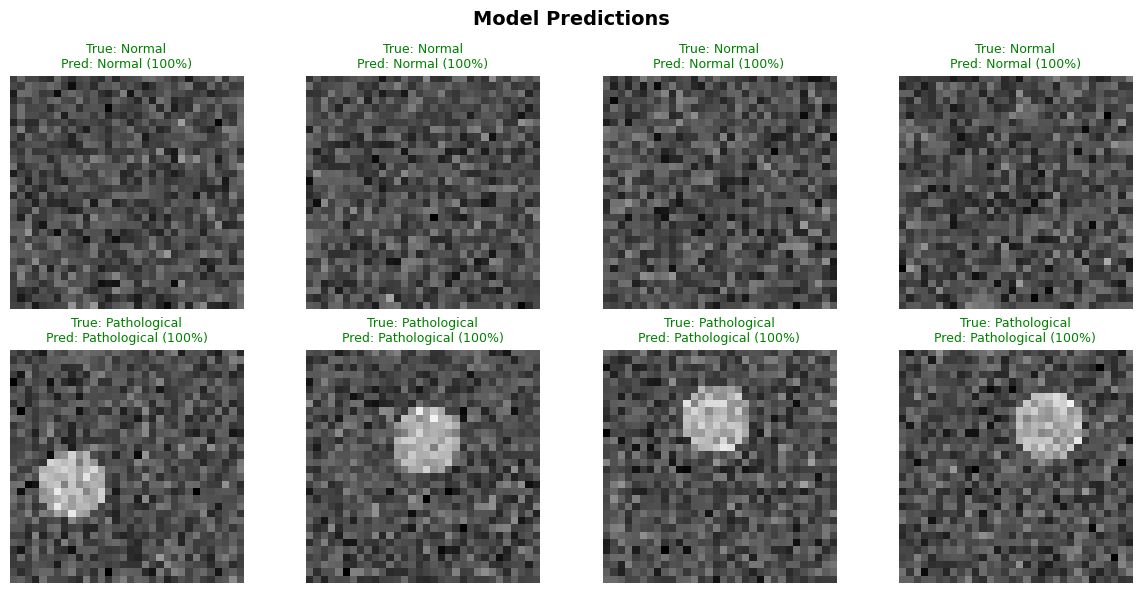


📊 Total accuracy: 200/200 = 100.0%


In [11]:
# === Test the model on new images ===
cnn_model.eval()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Model Predictions', fontsize=14, fontweight='bold')

test_indices = [0, 5, 10, 15, 100, 105, 110, 115]  # Mix of normal/pathological

for idx, ax in zip(test_indices, axes.flat):
    image, true_label = dataset[idx]
    
    # Prediction
    with torch.no_grad():
        output = cnn_model(image.unsqueeze(0))
        probabilities = torch.softmax(output, dim=1)
        prediction = output.argmax(dim=1).item()
    
    # Display image
    ax.imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1)
    
    # Color based on correct/incorrect
    color = 'green' if prediction == true_label else 'red'
    true_text = 'Normal' if true_label == 0 else 'Pathological'
    pred_text = 'Normal' if prediction == 0 else 'Pathological'
    confidence = probabilities[0, prediction].item()
    
    ax.set_title(f'True: {true_text}\nPred: {pred_text} ({confidence:.0%})', 
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Calculate total accuracy
correct = 0
for i in range(len(dataset)):
    image, label = dataset[i]
    with torch.no_grad():
        pred = cnn_model(image.unsqueeze(0)).argmax(dim=1).item()
    if pred == label:
        correct += 1

print(f"\n📊 Total accuracy: {correct}/{len(dataset)} = {correct/len(dataset):.1%}")


---

## Part 2: CNN on 1D Signals (EEG)

CNNs don't just work on images! With **1D convolution** we can analyze time series data such as:
- ECG (heart rhythm)
- EEG (brain activity)
- Respiratory signals

### Example 7: Epilepsy Detection from EEG

We simulate EEG signals and classify them as **normal** or **seizure**.


In [12]:
# === Synthetic EEG dataset ===
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

class SyntheticEEGDataset(Dataset):
    """
    Simulates EEG signals (1D time series, 256 samples ≈ 1.5 sec at 173 Hz).
    - Normal: Calm alpha activity (~10 Hz sine wave + noise)
    - Seizure: High-frequency spiking (~25 Hz) with irregular amplitude
    """
    def __init__(self, n_samples=200, signal_length=256):
        self.signals = []
        self.labels = []
        t = np.linspace(0, 1.5, signal_length)
        
        for i in range(n_samples):
            if i < n_samples // 2:
                # Normal: calm alpha rhythm
                signal = 0.5 * np.sin(2 * np.pi * 10 * t) + 0.1 * np.random.randn(signal_length)
                label = 0
            else:
                # Seizure: high-frequency, irregular activity
                signal = (0.8 * np.sin(2 * np.pi * 25 * t) * (1 + 0.5 * np.sin(2 * np.pi * 3 * t))
                         + 0.3 * np.random.randn(signal_length))
                label = 1
            
            self.signals.append(torch.tensor(signal, dtype=torch.float32).unsqueeze(0))
            self.labels.append(label)
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        return self.signals[idx], self.labels[idx]

# Create dataset
eeg_dataset = SyntheticEEGDataset(n_samples=200)
print(f"EEG dataset: {len(eeg_dataset)} signals, shape: {eeg_dataset[0][0].shape}")


EEG dataset: 200 signals, shape: torch.Size([1, 256])


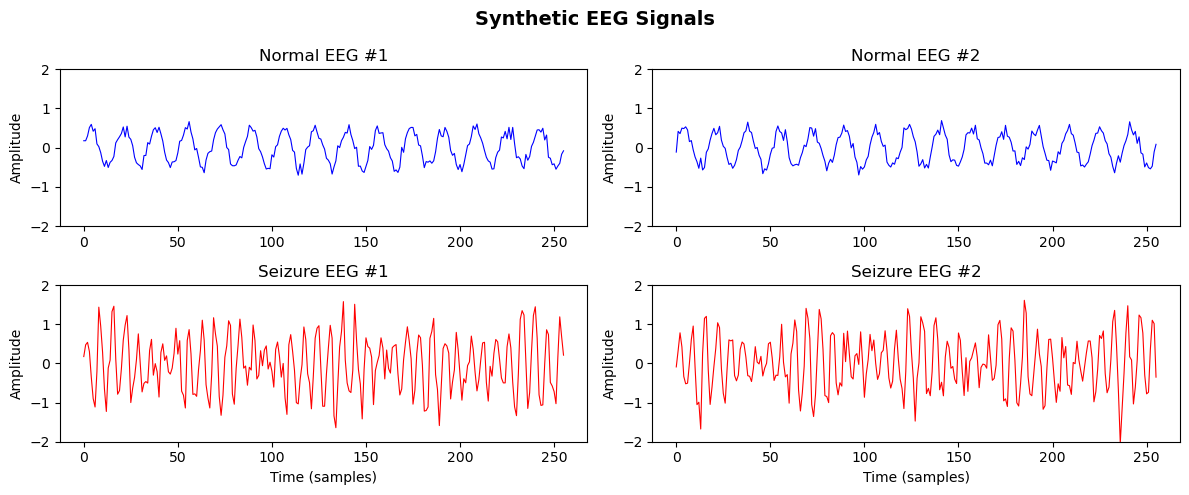

🧠 Normal: Steady ~10 Hz alpha activity
⚡ Seizure: High-frequency (~25 Hz), irregular amplitude


In [13]:
# === Visualize EEG examples ===
fig, axes = plt.subplots(2, 2, figsize=(12, 5))
fig.suptitle('Synthetic EEG Signals', fontsize=14, fontweight='bold')

# Normal signals
for i, ax in enumerate(axes[0]):
    signal, _ = eeg_dataset[i]
    ax.plot(signal.squeeze().numpy(), 'b-', linewidth=0.8)
    ax.set_title(f'Normal EEG #{i+1}')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-2, 2)

# Seizure signals
for i, ax in enumerate(axes[1]):
    signal, _ = eeg_dataset[100 + i]
    ax.plot(signal.squeeze().numpy(), 'r-', linewidth=0.8)
    ax.set_title(f'Seizure EEG #{i+1}')
    ax.set_xlabel('Time (samples)')
    ax.set_ylabel('Amplitude')
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

print("🧠 Normal: Steady ~10 Hz alpha activity")
print("⚡ Seizure: High-frequency (~25 Hz), irregular amplitude")


In [14]:
# === 1D-CNN for EEG classification ===
try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class EEGClassifier(pl.LightningModule):
    """
    1D-CNN for EEG classification.
    Uses Conv1d instead of Conv2d!
    """
    def __init__(self):
        super().__init__()
        
        # 1D convolutional layers
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),   # (1, 256) → (16, 256)
            nn.ReLU(),
            nn.MaxPool1d(4),                               # (16, 256) → (16, 64)
            nn.Conv1d(16, 32, kernel_size=5, padding=2),  # (16, 64) → (32, 64)
            nn.ReLU(),
            nn.MaxPool1d(4),                               # (32, 64) → (32, 16)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # Normal vs Seizure
        )
        
        self.loss_function = nn.CrossEntropyLoss()
    
    def forward(self, x):
        return self.classifier(self.features(x))
    
    def training_step(self, batch, batch_idx):
        signals, labels = batch
        pred = self(signals)
        loss = self.loss_function(pred, labels)
        accuracy = (pred.argmax(dim=1) == labels).float().mean()
        self.log('loss', loss, prog_bar=True)
        self.log('accuracy', accuracy, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

eeg_model = EEGClassifier()
print("1D-CNN for EEG:")
print(f"  Conv1d: 1→16→32 channels")
print(f"  Input: (batch, 1, 256) → Output: (batch, 2)")


1D-CNN for EEG:
  Conv1d: 1→16→32 channels
  Input: (batch, 1, 256) → Output: (batch, 2)


In [15]:
# === Train and evaluate the EEG model ===
import platform

eeg_dataloader = DataLoader(
    eeg_dataset, batch_size=32, shuffle=True,
    num_workers=0 if platform.system() == 'Darwin' else 4
)

trainer = pl.Trainer(max_epochs=15, enable_progress_bar=True, 
                    enable_model_summary=False, logger=False)

print("Training 1D-CNN on EEG data...")
trainer.fit(eeg_model, eeg_dataloader)

# Evaluate
eeg_model.eval()
correct = sum(1 for i in range(len(eeg_dataset)) 
               if eeg_model(eeg_dataset[i][0].unsqueeze(0)).argmax().item() == eeg_dataset[i][1])

print(f"\n✅ Accuracy: {correct}/{len(eeg_dataset)} = {correct/len(eeg_dataset):.1%}")


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Output()

Training 1D-CNN on EEG data...


`Trainer.fit` stopped: `max_epochs=15` reached.



✅ Accuracy: 200/200 = 100.0%


---

## Summary

### What we learned in this notebook:

| Part | Data type | CNN type | Medical application |
|------|-----------|----------|---------------------|
| **Part 1** | 2D images (32×32) | `Conv2d` | X-ray, CT, MRI classification |
| **Part 2** | 1D signals (256 samples) | `Conv1d` | EEG, ECG, respiration |

### Key differences: 2D vs 1D CNN

```
2D-CNN (images):         1D-CNN (signals):
┌───────────┐            ┌─────────────────────┐
│  ■ ■ ■ ■  │            │ ～～～～～～～～～～ │
│  ■ ■ ■ ■  │   vs       └─────────────────────┘
│  ■ ■ ■ ■  │            
└───────────┘            Conv1d(in, out, kernel)
Conv2d(in, out, kernel)  MaxPool1d(size)
MaxPool2d(size)          
```

### Further exploration

- **Real data**: Download the [Bonn EEG dataset](https://www.upf.edu/web/ntsa/downloads) for real epilepsy signals
- **More advanced**: Try LSTM or Transformer architectures for time series data
- **Medical AI**: See [fastMONAI](https://github.com/MMIV-ML/fastMONAI) for 3D medical image analysis


---

## 🎯 Exercises

Try these exercises to test your understanding! Click "Show solution" to see suggested solutions.

---

### Exercise 1: Tensor Operations

Create a tensor representing **5 patients** with **4 blood test values** each (Hb, leukocytes, platelets, CRP). Then calculate:
1. The mean value for each blood test type (across all patients)
2. Normalize the data (subtract mean, divide by standard deviation)

<details>
<summary>💡 Show solution</summary>

```python
import torch

# 5 patients × 4 blood test values
blood_tests = torch.tensor([
    [14.0, 7.5, 250.0, 5.0],   # Patient 1
    [12.5, 9.0, 180.0, 45.0],  # Patient 2
    [15.2, 6.8, 300.0, 3.0],   # Patient 3
    [11.0, 12.0, 150.0, 80.0], # Patient 4
    [13.8, 8.2, 220.0, 12.0],  # Patient 5
])

# 1. Mean per blood test type (across patients, dim=0)
mean = blood_tests.mean(dim=0)
print(f"Mean: Hb={mean[0]:.1f}, Leuk={mean[1]:.1f}, "
      f"Plat={mean[2]:.1f}, CRP={mean[3]:.1f}")

# 2. Normalize
std = blood_tests.std(dim=0)
normalized = (blood_tests - mean) / std
print(f"\nNormalized data:\n{normalized}")
```

</details>


---

### Exercise 2: Modify Network Architecture

Start with the `SimpleClassifier` class from example 2. Extend it to have **3 hidden layers** with 16, 8, and 4 neurons respectively, and use **ReLU** activation between layers.

<details>
<summary>💡 Show solution</summary>

```python
import torch
import torch.nn as nn

class ExtendedClassifier(nn.Module):
    def __init__(self, input_size=4):
        super().__init__()
        self.layer1 = nn.Linear(input_size, 16)
        self.layer2 = nn.Linear(16, 8)
        self.layer3 = nn.Linear(8, 4)
        self.output = nn.Linear(4, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.sigmoid(self.output(x))
        return x

# Test the model
model = ExtendedClassifier()
print(f"Model architecture:\n{model}")
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters())}")

# Test with dummy data
test_input = torch.randn(3, 4)  # 3 patients, 4 features
output = model(test_input)
print(f"\nInput shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
```

</details>

---

### Exercise 3: Experiment with Learning Rate

Use the training loop from example 3. Run training with three different learning rates: `0.001`, `0.1`, and `1.0`. 
What do you observe? Which learning rate gives the best result?

<details>
<summary>💡 Show solution</summary>

```python
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Simple model
def create_model():
    return nn.Sequential(
        nn.Linear(4, 8),
        nn.ReLU(),
        nn.Linear(8, 1),
        nn.Sigmoid()
    )

# Synthetic data
torch.manual_seed(42)
X = torch.randn(100, 4)
y = ((X[:, 0] + X[:, 1]) > 0).float().unsqueeze(1)

# Test different learning rates
learning_rates = [0.001, 0.1, 1.0]
results = {}

for lr in learning_rates:
    torch.manual_seed(42)  # Same starting point
    model = create_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_function = nn.BCELoss()
    
    loss_history = []
    for epoch in range(100):
        pred = model(X)
        loss = loss_function(pred, y)
        loss_history.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    results[lr] = loss_history
    print(f"LR={lr}: Final loss = {loss_history[-1]:.4f}")

# Visualize
plt.figure(figsize=(10, 4))
for lr, loss in results.items():
    plt.plot(loss, label=f'LR={lr}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Effect of Learning Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Observation:
# - LR=0.001: Slow convergence, but stable
# - LR=0.1: Good balance between speed and stability
# - LR=1.0: Too high - loss may oscillate or explode
```

</details>

---

### Exercise 4: Modify CNN Architecture

In `MedicalImageCNN` from example 6, add a **third convolutional layer** with 64 filters. Remember to update the `self.fc` layer accordingly.

*Hint: After an extra convolutional layer with stride=2, the dimensions are halved again.*

<details>
<summary>💡 Show solution</summary>

```python
import torch
import torch.nn as nn
try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class DeeperImageCNN(pl.LightningModule):
    def __init__(self):
        super().__init__()
        # 3 convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)  # 32→16
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1) # 16→8
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1) # 8→4
        self.relu = nn.ReLU()
        
        # After 3 convolutions: 64 channels × 4 × 4 = 1024
        self.fc = nn.Linear(64 * 4 * 4, 2)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))  # [B, 16, 16, 16]
        x = self.relu(self.conv2(x))  # [B, 32, 8, 8]
        x = self.relu(self.conv3(x))  # [B, 64, 4, 4]
        x = x.view(x.size(0), -1)     # [B, 1024]
        x = self.fc(x)                # [B, 2]
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = nn.CrossEntropyLoss()(pred, y)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

# Verify dimensions
model = DeeperImageCNN()
test_input = torch.randn(2, 1, 32, 32)  # 2 images
output = model(test_input)
print(f"Input: {test_input.shape}")
print(f"Output: {output.shape}")
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters()):,}")
```

</details>

---

### Exercise 5: From 2D to 1D CNN

Convert `MedicalImageCNN` to a **1D-CNN** that can classify ECG signals with length 200 (sampling points). The model should have:
- Input: 200 sampling points (1 channel)
- 2 convolutional layers (16 and 32 filters)
- Output: 3 classes (normal, arrhythmia_A, arrhythmia_B)

<details>
<summary>💡 Show solution</summary>

```python
import torch
import torch.nn as nn
try:
    import lightning.pytorch as pl
except ImportError:
    import pytorch_lightning as pl

class ECGCNN(pl.LightningModule):
    def __init__(self, signal_length=200, n_classes=3):
        super().__init__()
        # 1D convolutional layers (Conv1d)
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, stride=2, padding=2)   # 200→100
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2)  # 100→50
        self.pool = nn.AdaptiveAvgPool1d(10)  # Reduce to fixed size
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
        # Fully connected layer
        self.fc = nn.Linear(32 * 10, n_classes)
    
    def forward(self, x):
        # x: [batch, 1, 200]
        x = self.relu(self.conv1(x))   # [B, 16, 100]
        x = self.relu(self.conv2(x))   # [B, 32, 50]
        x = self.pool(x)               # [B, 32, 10]
        x = x.view(x.size(0), -1)      # [B, 320]
        x = self.dropout(x)
        x = self.fc(x)                 # [B, 3]
        return x
    
    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = nn.CrossEntropyLoss()(pred, y)
        acc = (pred.argmax(dim=1) == y).float().mean()
        self.log('train_acc', acc)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

# Test the model
model = ECGCNN()
print(f"Model:\n{model}")

# Synthetic ECG batch
ecg_batch = torch.randn(8, 1, 200)  # 8 ECG signals
output = model(ecg_batch)

print(f"\nInput shape: {ecg_batch.shape}")
print(f"Output shape: {output.shape}")
print(f"Predictions: {torch.softmax(output[0], dim=0)}")
print(f"\nNumber of parameters: {sum(p.numel() for p in model.parameters()):,}")
```

</details>

---

### 🏆 Congratulations!

You have now completed the exercises for PyTorch and Lightning. If you want to explore more:

- **A3-A6**: Practical MNIST examples with increasing complexity
- **B1-B4**: Neural networks and medical classification
- **C1-C4**: Deeper CNN understanding with image classification

> 💡 **Tip**: Try combining what you've learned – e.g., use Lightning on the MNIST dataset from A3!